In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")


In [15]:
x_test  = pd.read_csv("../data/X_test.csv")
y_test  = pd.read_csv("../data/y_test.csv").squeeze()

xgb_model = joblib.load("../models/xgboost_model.pkl")
rf_model  = joblib.load("../models/random_forest_model.pkl")
print(f"Test data shape: {x_test.shape}")

Test data shape: (24053, 21)


In [16]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=x_test.columns
).sort_values(ascending=False)
for i, (feat, score) in enumerate(xgb_importance.head(10).items(), 1):
    print(f"{i:2}. {feat:<40} {score:.4f}")

 1. CreditUtilCategory_Medium                0.2729
 2. CreditUtilCategory_Very High             0.1768
 3. CreditUtilCategory_High                  0.1440
 4. AgeGroup_Young                           0.0773
 5. AgeGroup_Elderly                         0.0754
 6. RevolvingUtilizationOfUnsecuredLines     0.0548
 7. AgeGroup_Middle                          0.0441
 8. AgeGroup_Senior                          0.0404
 9. TotalTimesLate                           0.0342
10. NumberOfTimes90DaysLate                  0.0145


In [17]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=x_test.columns
).sort_values(ascending=False)
for i, (feat, score) in enumerate(rf_importance.head(10).items(), 1):
    print(f"{i:2}. {feat:<40} {score:.4f}")

 1. RevolvingUtilizationOfUnsecuredLines     0.2738
 2. TotalTimesLate                           0.1502
 3. AgeGroup_Senior                          0.0843
 4. CreditUtilCategory_Medium                0.0833
 5. age                                      0.0800
 6. AgeGroup_Elderly                         0.0592
 7. AgeGroup_Middle                          0.0551
 8. NumberOfTime30-59DaysPastDueNotWorse     0.0393
 9. CreditUtilCategory_High                  0.0387
10. AgeGroup_Young                           0.0342


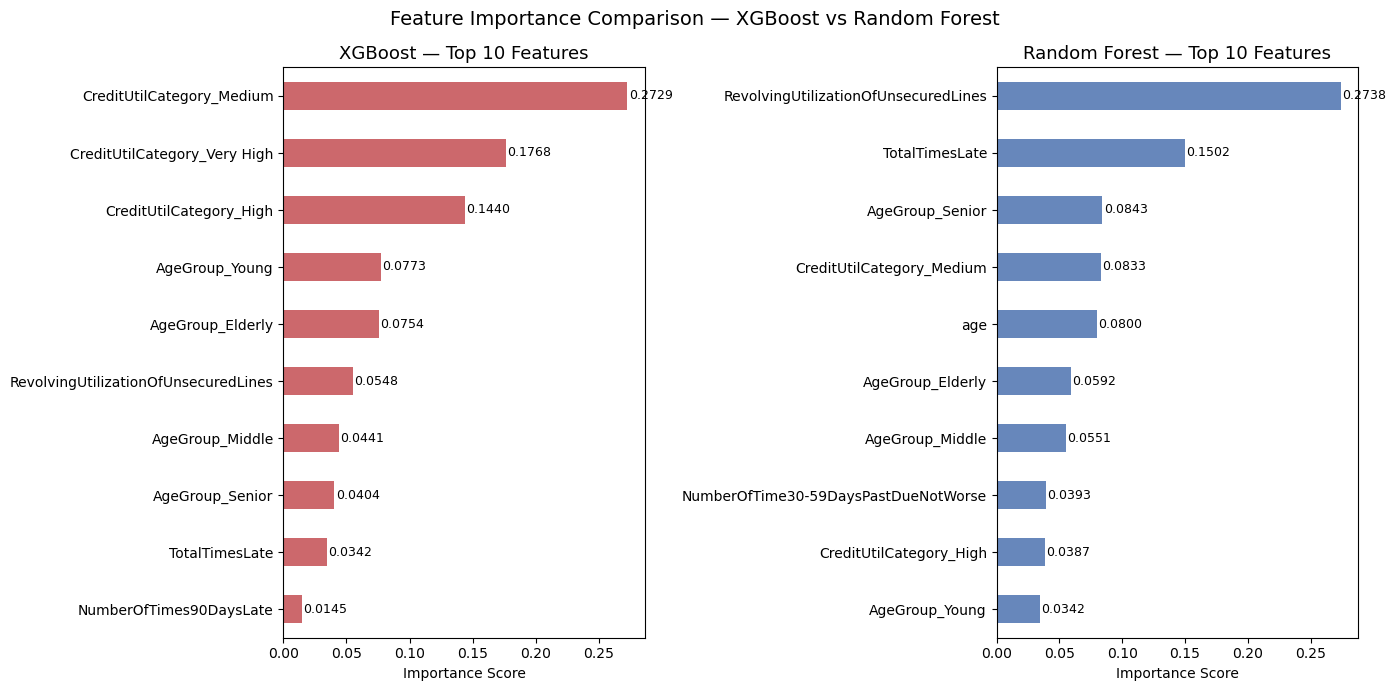

Chart saved to outputs/day9_feature_importance.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# XGBoost
top_xgb = xgb_importance.head(10).sort_values(ascending=True)
top_xgb.plot(kind="barh", ax=axes[0], color="#C44E52", alpha=0.85)
axes[0].set_title("XGBoost — Top 10 Features", fontsize=13)
axes[0].set_xlabel("Importance Score")
for i, v in enumerate(top_xgb.values):
    axes[0].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)

# Random Forest
top_rf = rf_importance.head(10).sort_values(ascending=True)
top_rf.plot(kind="barh", ax=axes[1], color="#4C72B0", alpha=0.85)
axes[1].set_title("Random Forest — Top 10 Features", fontsize=13)
axes[1].set_xlabel("Importance Score")
for i, v in enumerate(top_rf.values):
    axes[1].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)

plt.suptitle("Feature Importance Comparison — XGBoost vs Random Forest",
             fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/day9_feature_importance.png", dpi=150)
plt.show()
print("Chart saved to outputs/day9_feature_importance.png")

In [19]:
comparison = pd.DataFrame({
    "XGBoost Top Features"      : xgb_importance.head(10).index.tolist(),
    "XGBoost Score"             : xgb_importance.head(10).values.round(4),
    "RF Top Features"           : rf_importance.head(10).index.tolist(),
    "RF Score"                  : rf_importance.head(10).values.round(4),
})

print(comparison.to_string(index=False))

comparison.to_csv("../outputs/day9_feature_comparison.csv", index=False)
print("\nSaved to outputs/day9_feature_comparison.csv")

                XGBoost Top Features  XGBoost Score                      RF Top Features  RF Score
           CreditUtilCategory_Medium         0.2729 RevolvingUtilizationOfUnsecuredLines    0.2738
        CreditUtilCategory_Very High         0.1768                       TotalTimesLate    0.1502
             CreditUtilCategory_High         0.1440                      AgeGroup_Senior    0.0843
                      AgeGroup_Young         0.0773            CreditUtilCategory_Medium    0.0833
                    AgeGroup_Elderly         0.0754                                  age    0.0800
RevolvingUtilizationOfUnsecuredLines         0.0548                     AgeGroup_Elderly    0.0592
                     AgeGroup_Middle         0.0441                      AgeGroup_Middle    0.0551
                     AgeGroup_Senior         0.0404 NumberOfTime30-59DaysPastDueNotWorse    0.0393
                      TotalTimesLate         0.0342              CreditUtilCategory_High    0.0387
          

In [20]:

y_prob = xgb_model.predict_proba(x_test)[:, 1]

high_risk_idx = y_prob.argmax()
low_risk_idx  = y_prob.argmin()


print("HIGHEST RISK PERSON")

high_risk = x_test.iloc[high_risk_idx]
print(f"Default probability : {y_prob[high_risk_idx]:.4f}")
print(f"Actual label        : {y_test.iloc[high_risk_idx]}")
print("\nTop 5 risky features:")
top5 = xgb_importance.head(5).index.tolist()
for feat in top5:
    print(f"  {feat:<40}: {high_risk[feat]:.4f}")

print("LOWEST RISK PERSON")

low_risk = x_test.iloc[low_risk_idx]
print(f"Default probability : {y_prob[low_risk_idx]:.4f}")
print(f"Actual label        : {y_test.iloc[low_risk_idx]}")
print("\nTop 5 features for safe person:")
for feat in top5:
    print(f"  {feat:<40}: {low_risk[feat]:.4f}")

HIGHEST RISK PERSON
Default probability : 0.9394
Actual label        : 1

Top 5 risky features:
  CreditUtilCategory_Medium               : 0.0000
  CreditUtilCategory_Very High            : 1.0000
  CreditUtilCategory_High                 : 0.0000
  AgeGroup_Young                          : 0.0000
  AgeGroup_Elderly                        : 0.0000
LOWEST RISK PERSON
Default probability : 0.0007
Actual label        : 0

Top 5 features for safe person:
  CreditUtilCategory_Medium               : 0.0000
  CreditUtilCategory_Very High            : 0.0000
  CreditUtilCategory_High                 : 0.0000
  AgeGroup_Young                          : 0.0000
  AgeGroup_Elderly                        : 1.0000
